In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ 0.92186198,  2.83363088],
       [-0.44010478,  8.05374244],
       [-1.10782744,  7.04018121],
       ...,
       [ 1.69180067,  1.90667183],
       [ 7.4648905 ,  5.45758043],
       [ 1.59275222,  3.59606149]], shape=(1000, 2))

In [4]:
y

array([2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 0, 0, 2, 0, 2, 1, 2, 1, 1, 0, 0,
       2, 0, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 0, 2,
       0, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 1, 1, 2, 0, 1, 0, 1, 1, 0, 2, 1,
       0, 2, 0, 0, 1, 0, 1, 1, 0, 2, 1, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 0, 2,
       1, 1, 1, 2, 1, 2, 2, 0, 1, 2, 0, 2, 1, 2, 0, 1, 1, 1, 0, 0, 0, 1,
       2, 1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2,
       2, 2, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 2,
       2, 2, 0, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 0, 1, 2, 1,
       1, 0, 2, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2, 0, 1, 0, 2, 1, 2, 1, 2, 0,
       1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 0, 1, 2, 1, 2, 1, 0, 2, 2, 0, 1, 1,
       0, 0, 0, 2, 1, 1, 1, 2, 2, 1, 0, 1, 1, 1, 1,

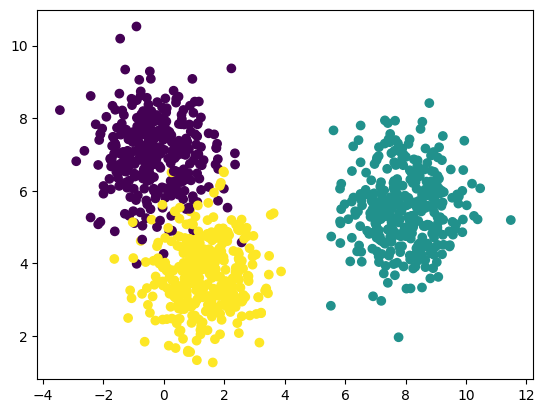

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [19]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
from sklearn.cluster import KMeans


In [21]:
#elbow method to select k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [22]:
print(wcss)

[1340.0000000000005, 737.3633238997287, 253.64013102368884, 206.96957710987715, 152.72531119304014, 119.14282647567254, 103.77224186255758, 92.72877326900425, 85.62840246153552, 79.57843789558713]


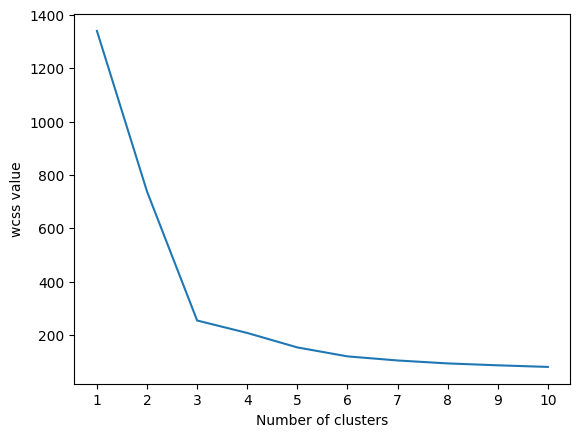

In [23]:
#ploting elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss value")
plt.show()

In [24]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 0,
       1, 2, 1, 2, 1, 0, 2, 1, 2, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 2, 1, 1,
       1, 0, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2,
       2, 0, 2, 2, 0, 1, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 2, 1, 1,
       0, 1, 1, 1, 1, 1, 2, 2, 1, 0, 1, 2, 1, 1, 0, 2, 2, 0, 1, 2, 2, 0,
       0, 2, 0, 1, 1, 2, 1, 2, 2, 0, 1, 2, 1, 0, 2, 0, 0, 1, 1, 1, 0, 1,
       2, 0, 0, 0, 2, 2, 1, 2, 1, 1, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1,
       2, 2, 0, 0, 1, 2, 2, 1, 0, 0, 1, 0, 0, 2, 1, 0, 2, 2, 0, 2, 2, 1,
       1, 0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0,
       2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2,
       1, 0, 0, 2, 2, 0, 2, 0, 0, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 1, 1,
       2, 0, 2, 2, 0, 1, 2, 1, 1, 1, 2, 0, 2, 0, 1, 0, 0, 2, 2, 0, 2, 2,
       1, 2, 0, 2, 2, 1, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 2, 0, 0, 1, 1, 0,
       2, 1, 2, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1,

In [25]:
y_pred=kmeans.predict(X_test_scaled)

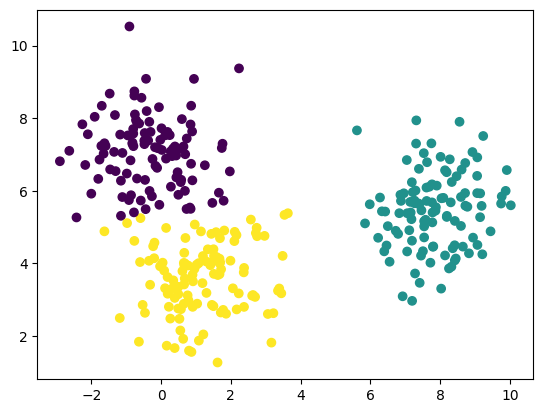

In [26]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [27]:
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
#validating k value
#knee locator
#silhoutee scoring

In [29]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [30]:
kl.elbow

np.int64(3)

In [31]:
#silhoutee scoring
from sklearn.metrics import silhouette_score

In [32]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)


In [33]:
silhouette_coefficients

[0.4475747528527697,
 0.620333528681937,
 0.5246409486152409,
 0.5219624985289727,
 0.42403285793544426,
 0.40087091641755945,
 0.3766747937068761,
 0.3678854377184268,
 0.34062540517695594]

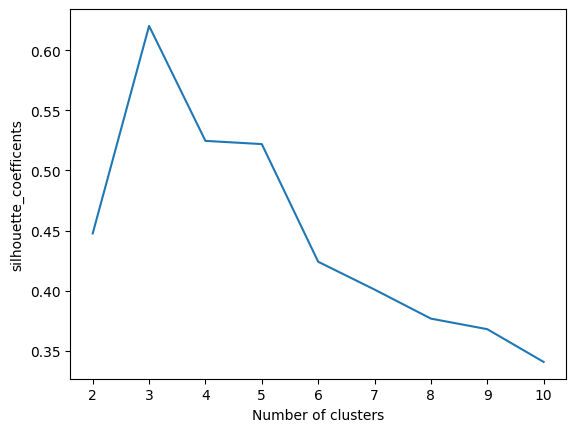

In [34]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_coefficents")
plt.show()